# Atividade 3 -- Tópicos para Computação 1 -- 2026.1

- Escola Superior de Tecnologia
- Profa. Dra. Elloá B. Guedes (ebgcosta@uea.edu.br)
- www.elloaguedes.com
- github.com/elloa
- Data: 19 de março de 2026

## Descrição

A atividade consiste em construir uma rede neural convolucional para classificar o _Stanford Dogs Dataset_, um dataset com imagens de 120 raças de cachorro de todo o mundo e mais de 20 mil imagens para treino e teste.

## Material de Referência para Estudo

- http://vision.stanford.edu/aditya86/ImageNetDogs/


## Prazos importantes

- Data de entrega: 23/03/2026
- Modo de entrega: Google Classroom
- Estratégia de desenvolvimento: Quartetos (a interseção com grupos anteriores deve ter tamanho máximo igual a 2)

## Equipe:
- Ana Flavia de Castro Segadillha da Silva
- Davi Aguiar Moreira
- Luiz Fernando Borges Brito
- Pedro Vitor Barros Maranhao

In [49]:
import os
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
import random
from torchvision import transforms as T

# Obtenção do dataset

- A tarefa a ser considerada é uma tarefa de classificação multiclasse
- A documentação oficial do dataset pode ser obtida aqui: http://vision.stanford.edu/aditya86/ImageNetDogs/
- Vamos usar essa versão do Kaggle em que as imagens e rótulos já estão organizados:
  https://www.kaggle.com/datasets/miljan/stanford-dogs-dataset-traintest
- Instale a API do Kaggle e faça o download do dataset usando Python
- Organize o nome das classes, retire o identificador "n[id]" do início das pastas

In [11]:
path = kagglehub.dataset_download("miljan/stanford-dogs-dataset-traintest")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\anafl\.cache\kagglehub\datasets\miljan\stanford-dogs-dataset-traintest\versions\1


In [12]:
#Criação de novos paths para acessar os dados de treino e teste

novo_path = os.path.join(path, "cropped")

test_path = os.path.join(novo_path, "test")

train_path = os.path.join(novo_path, "train")

In [6]:
#Função para retirar "n[id]" do início das pastas buscando por "-"
def tirar_id(path):
    for item in os.listdir(path):
        nome_bruto = os.path.join(path, item)
        segmentado = item.split("-", 1)     
        novo_nome = segmentado[1]
        nome_limpo = os.path.join(path, novo_nome)   
        os.rename(nome_bruto, nome_limpo)

tirar_id(test_path)
tirar_id(train_path)

In [13]:
print(os.listdir(test_path)[:10])
print(os.listdir(train_path)[:10])

['affenpinscher', 'Afghan_hound', 'African_hunting_dog', 'Airedale', 'American_Staffordshire_terrier', 'Appenzeller', 'Australian_terrier', 'basenji', 'basset', 'beagle']
['affenpinscher', 'Afghan_hound', 'African_hunting_dog', 'Airedale', 'American_Staffordshire_terrier', 'Appenzeller', 'Australian_terrier', 'basenji', 'basset', 'beagle']


# Transformações na Entrada, Image Handler e Data Loader

- As imagens precisam ser padronizadas, vamos usar as dimensões 224x224 e a normalização das cores
- Transformação das Imagens: https://docs.pytorch.org/vision/0.8/transforms.html
- Operações: Redimensionamento, Para Tensor e Normalização ([-1,1] com média 0.5 e desvio padrão de 0.5)
- Criar um ImageHandler para cada pasta (treino/teste):
  - https://docs.pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html#torchvision.datasets.ImageFolder
- Para o treinamento: criar um Data loader com tamanho de lote igual a 32 e randomização
- https://docs.pytorch.org/docs/stable/data.html
- Para o teste: criar um Data loader com lote de tamanho igual a 1 e sem randomização

In [14]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],std =[0.5, 0.5, 0.5])
])

In [15]:
train_dataset = ImageFolder(root=train_path, transform=transform)
test_dataset  = ImageFolder(root=test_path, transform=transform)

In [16]:
train_load= DataLoader(train_dataset, batch_size=32, shuffle=True)
test_load = DataLoader(test_dataset)

In [17]:
#Teste para verificar se as transformações foram feitas

images, labels = next(iter(train_load))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


## Entendendo o Image Handler (dataset.ImageFolder) DataLoader

- Responda ao que se pede:
    1. Qual o papel do ImageHandler nesse contexto?
    2. E do DataLoader?
    3. Por que o tamanho do batch não pode ser todo o conjunto de dados?
    4. Por que o DataLoader do treinamento precisa de aleatoriedade?
    5. Por que o DataLoader do teste deve ter batch igual a 1 e sem aleatoriedade?

Respostas questões 1 e 2

O ImageHandler é responsável por aplicar as transformações descritas em cada uma das imagens presentes nos datasets de treino e teste. Por outro lado, o DataLoader é responsável por carregar as imagens do dataset e permitir a segmentação (com batch_size) e aplicação de aleatoriedade na ordem da imagens(com shuffle =True).

Resposta questão 3

O tamanho do batch não pode ser todo o conjunto de dados pois além de exigir uma grande quantidade de memória, o menor número de atualizações dos pesos por época pode resultar em modelos pouco generalistas que convergem para soluções não ótimas.

Respostas questões 4 e 5 

O DataLoader do treino necessita de aleatoriedade para evitar que o modelo aprenda padrões na ordem dos dados, contribuindo para um treinamento ineficaz que pode resultar em overfitting. Já o DataLoader do teste deve tem batch igual 1 e não possuir aleatoriedade para facilitar a reprodutibilidade dos resultados e visualização dos exemplos.

## Construindo sua primeira CNN: AlexNet

- Construa, camada a camada, a CNN AlexNet, vencedora do ImageNet 2012
- Arquitetura da AlexNet é dada a seguir:
1. Conv 1: 96 filtros de tamanho $11 \times 11$, com um stride (passo) de 4.
2. Max Pool 1: Redução espacial com janelas de $3 \times 3$ e stride 2.
3. Conv 2: 256 filtros de $5 \times 5$ com padding para manter a dimensão.
4. Max Pool 2: Outra redução de $3 \times 3$ com stride 2.
5. Conv 3, 4 e 5: Camadas convolucionais puras (sem pooling entre elas) com 384, 384 e 256 filtros de $3 \times 3$, respectivamente.
6. Max Pool 3: Última redução antes das camadas densas.
7. Camada de adaptação para classificação: Adaptive Average Pooling Bidimensional 6x6
8. FC 6 e 7: Duas camadas densas com 4096 neurônios cada, utilizando Dropout de 0.5 para reduzir o overfitting.
9. FC 8 (Saída): Camada final com ativação Softmax. Ajuste a camada de saída para o número de classes do problema encontrado.

### Sumário do Modelo

- Apresente o sumário do modelo, indicando quantos parâmetros ele possui e quantos destes são treináveis.


### Links Úteis

- https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
- https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.pooling.MaxPool2d.html
- https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.activation.ReLU.html
- https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.pooling.AdaptiveAvgPool2d.html
- https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.dropout.Dropout.html





In [18]:
class AlexNet(nn.Module):
    def __init__(self, dog_classes):
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True), nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(96, 256, kernel_size=5, padding=2), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2), nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True), nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True), nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True), nn.MaxPool2d(kernel_size=3, stride=2))
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(nn.Dropout(p=0.5), nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True), nn.Dropout(p=0.5), nn.Linear(4096, 4096),
            nn.ReLU(inplace=True), nn.Linear(4096, dog_classes), nn.Softmax(dim=1)) ## usando softmax por agora, mas olhando a documentação do PyTorch,
                                                                                    ## o CrossEntropyLoss que a gente usa depois é equivalente ao LogSoftmax,
                                                                                    ## então tem que calcular qual usar.
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [19]:
model = AlexNet(dog_classes=120)
print(model)
print(f"Número total de parâmetros: {sum(p.numel() for p in model.parameters())}")
print(f"Número de parâmetros treináveis: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

## Configuração do Treino

- 120 épocas
- Otimizador: Mini-batch SGD com Momentum (tal qual no paper original da AlexNet)
- Zere os gradientes do otimizador
- Lotes de 32
- Taxa de aprendizado: 10^(-3)
- Momentum: 0.9
- Função de perda: Entropia Cruzada Categórica
- Caso tenha disponibilidade, acelere o treino com GPU

### Monitorando o Treinamento

- Ao longo das épocas, armazene o loss e a acurácia no treino em um arquivo csv

#### Links Úteis

- https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html
- https://docs.pytorch.org/docs/stable/generated/torch.optim.SGD.html

In [14]:
epocas = 120
aprendizado = 1e-3
momentum = 0.9

criterion = nn.CrossEntropyLoss() ## 'Note that this case is equivalent to applying LogSoftmax on an input, followed by NLLLoss.'
                                  ## Bom verificar se esse é o caso.
optimizer = optim.SGD(model.parameters(), lr=aprendizado, momentum=momentum)

In [23]:
csv_file_path = "training_metrics.csv"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

pd.DataFrame(columns=["Epoch", "Loss", "Accuracy"]).to_csv(csv_file_path, index=False)

In [ ]:
for epoch in range(epocas):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in train_load:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_accuracy = 100. * correct / total

    pd.DataFrame([[epoch + 1, epoch_loss, epoch_accuracy]], columns=["Epoch", "Loss", "Accuracy"]).to_csv(csv_file_path, mode='a', header=False, index=False)

    print(f"Epoch {epoch + 1}/{epocas}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")


Epoch 1/120, Loss: 4.7875, Accuracy: 0.81%
Epoch 2/120, Loss: 4.7875, Accuracy: 0.77%
Epoch 3/120, Loss: 4.7875, Accuracy: 0.86%
Epoch 4/120, Loss: 4.7875, Accuracy: 0.97%
Epoch 5/120, Loss: 4.7875, Accuracy: 0.80%
Epoch 6/120, Loss: 4.7875, Accuracy: 0.83%
Epoch 7/120, Loss: 4.7875, Accuracy: 0.78%
Epoch 8/120, Loss: 4.7875, Accuracy: 0.84%
Epoch 9/120, Loss: 4.7875, Accuracy: 0.74%
Epoch 10/120, Loss: 4.7875, Accuracy: 0.86%
Epoch 11/120, Loss: 4.7875, Accuracy: 0.83%
Epoch 12/120, Loss: 4.7875, Accuracy: 0.91%
Epoch 13/120, Loss: 4.7875, Accuracy: 0.74%
Epoch 14/120, Loss: 4.7875, Accuracy: 0.71%
Epoch 15/120, Loss: 4.7875, Accuracy: 0.82%
Epoch 16/120, Loss: 4.7875, Accuracy: 0.79%
Epoch 17/120, Loss: 4.7875, Accuracy: 0.84%
Epoch 18/120, Loss: 4.7875, Accuracy: 0.84%
Epoch 19/120, Loss: 4.7875, Accuracy: 0.82%
Epoch 20/120, Loss: 4.7875, Accuracy: 0.95%
Epoch 21/120, Loss: 4.7875, Accuracy: 0.83%
Epoch 22/120, Loss: 4.7875, Accuracy: 0.77%
Epoch 23/120, Loss: 4.7875, Accuracy: 0.7

## Métricas do Treinamento

- Elabore um gráfico com a função de perda ao longo das épocas
- Elabore um gráfico com a acurácia do conjunto de treino ao longo das épocas
- Responda: O treino foi eficiente?

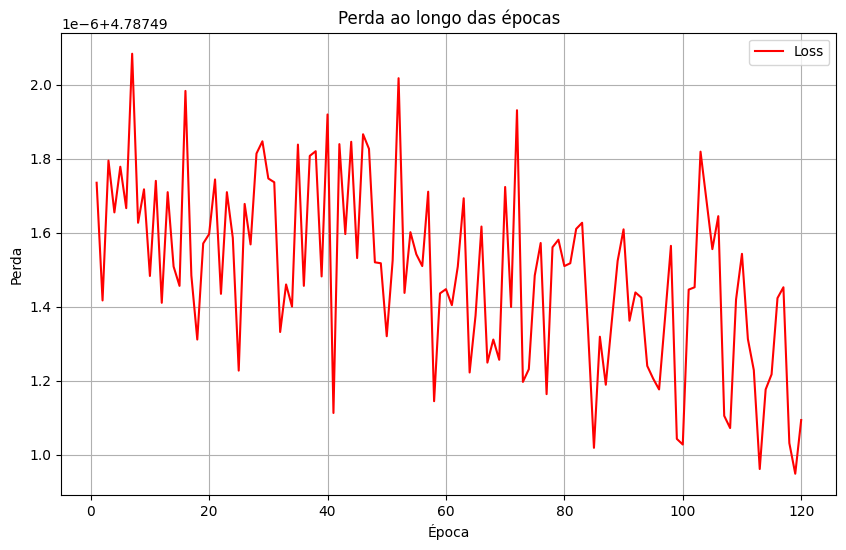

In [24]:
training_data = pd.read_csv("training_metrics.csv")

plt.figure(figsize=(10, 6))
plt.plot(training_data["Epoch"], training_data["Loss"], label="Loss", color="red")
plt.title("Perda ao longo das épocas")
plt.xlabel("Época")
plt.ylabel("Perda")
plt.legend()
plt.grid()
plt.show()


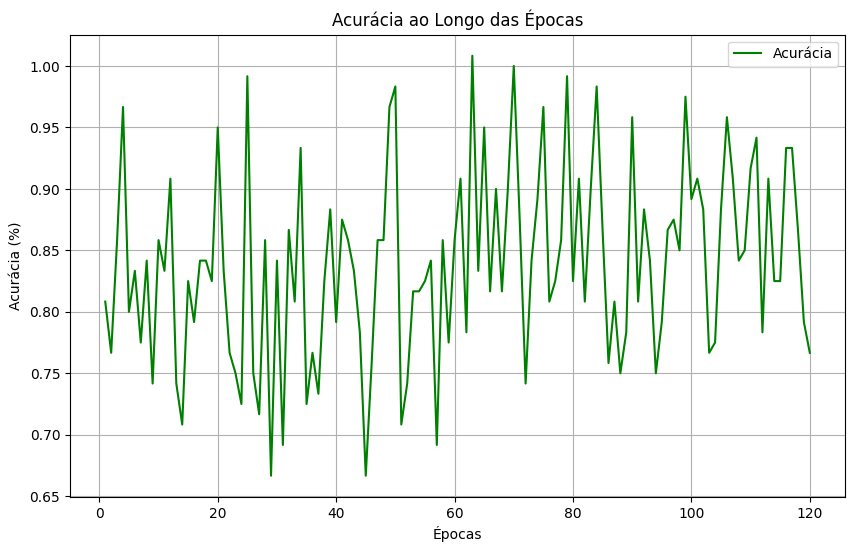

In [3]:
plt.figure(figsize=(10, 6))
plt.plot(training_data["Epoch"], training_data["Accuracy"], label="Acurácia", color="green")
plt.title("Acurácia ao Longo das Épocas")
plt.xlabel("Épocas")
plt.ylabel("Acurácia (%)")
plt.legend()
plt.grid()
plt.show()


Não, o treinamento não foi nada eficiente, pois a função de perda se manteve praticamente constante ao longo das épocas, indicando que o modelo não aprendeu nada significativo. Além disso, o valor final da acurácia é extremamente baixo.

### Persista o modelo

- Salvar o modelo com os pesos após o aprendizado é uma estratégia importante para posteriormente utilizá-lo para inferência ou para análises comparativas
- Nesta atividade, salve o modelo em disco e recupere-o para efetuar a avaliação no conjunto de testes

In [52]:
torch.save(model.state_dict(), "alexnet_dogs.pth") ## salvando

In [25]:
model_carregado = AlexNet(dog_classes=120) ## carregando
model_carregado.load_state_dict(torch.load("alexnet_dogs.pth", map_location=device))
model_carregado = model_carregado.to(device)
model_carregado.eval()

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

## Avaliação do Modelo

- Faça as inferências do modelo para o conjunto de testes e cálcule as métricas para uma tarefa de classificação multiclasse
- Elabore uma matriz de confusão
- Escolha três exemplos aleatórios do conjunto de testes, exiba-as e mostre também as top-3 probabilidades de classificação

In [29]:
pred = []
label = []

model_carregado.eval()
with torch.no_grad():
    for inputs, labels in test_load:
        inputs = inputs.to(device)
        outputs = model_carregado(inputs)
        _, predicted = outputs.max(1)
        pred.extend(predicted.cpu().numpy())
        label.extend(labels.cpu().numpy())

print(classification_report(label, pred, target_names=test_dataset.classes))

                                precision    recall  f1-score   support

                  Afghan_hound       0.00      0.00      0.00       139
           African_hunting_dog       0.00      0.00      0.00        69
                      Airedale       0.00      0.00      0.00       102
American_Staffordshire_terrier       0.00      0.00      0.00        64
                   Appenzeller       0.00      0.00      0.00        51
            Australian_terrier       0.00      0.00      0.00        96
            Bedlington_terrier       0.00      0.00      0.00        82
          Bernese_mountain_dog       0.00      0.00      0.00       118
              Blenheim_spaniel       0.00      0.00      0.00        88
                 Border_collie       0.00      0.00      0.00        50
                Border_terrier       0.00      0.00      0.00        72
                   Boston_bull       0.00      0.00      0.00        82
          Bouvier_des_Flandres       0.00      0.00      0.00  

c:\Users\anafl\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\anafl\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\anafl\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

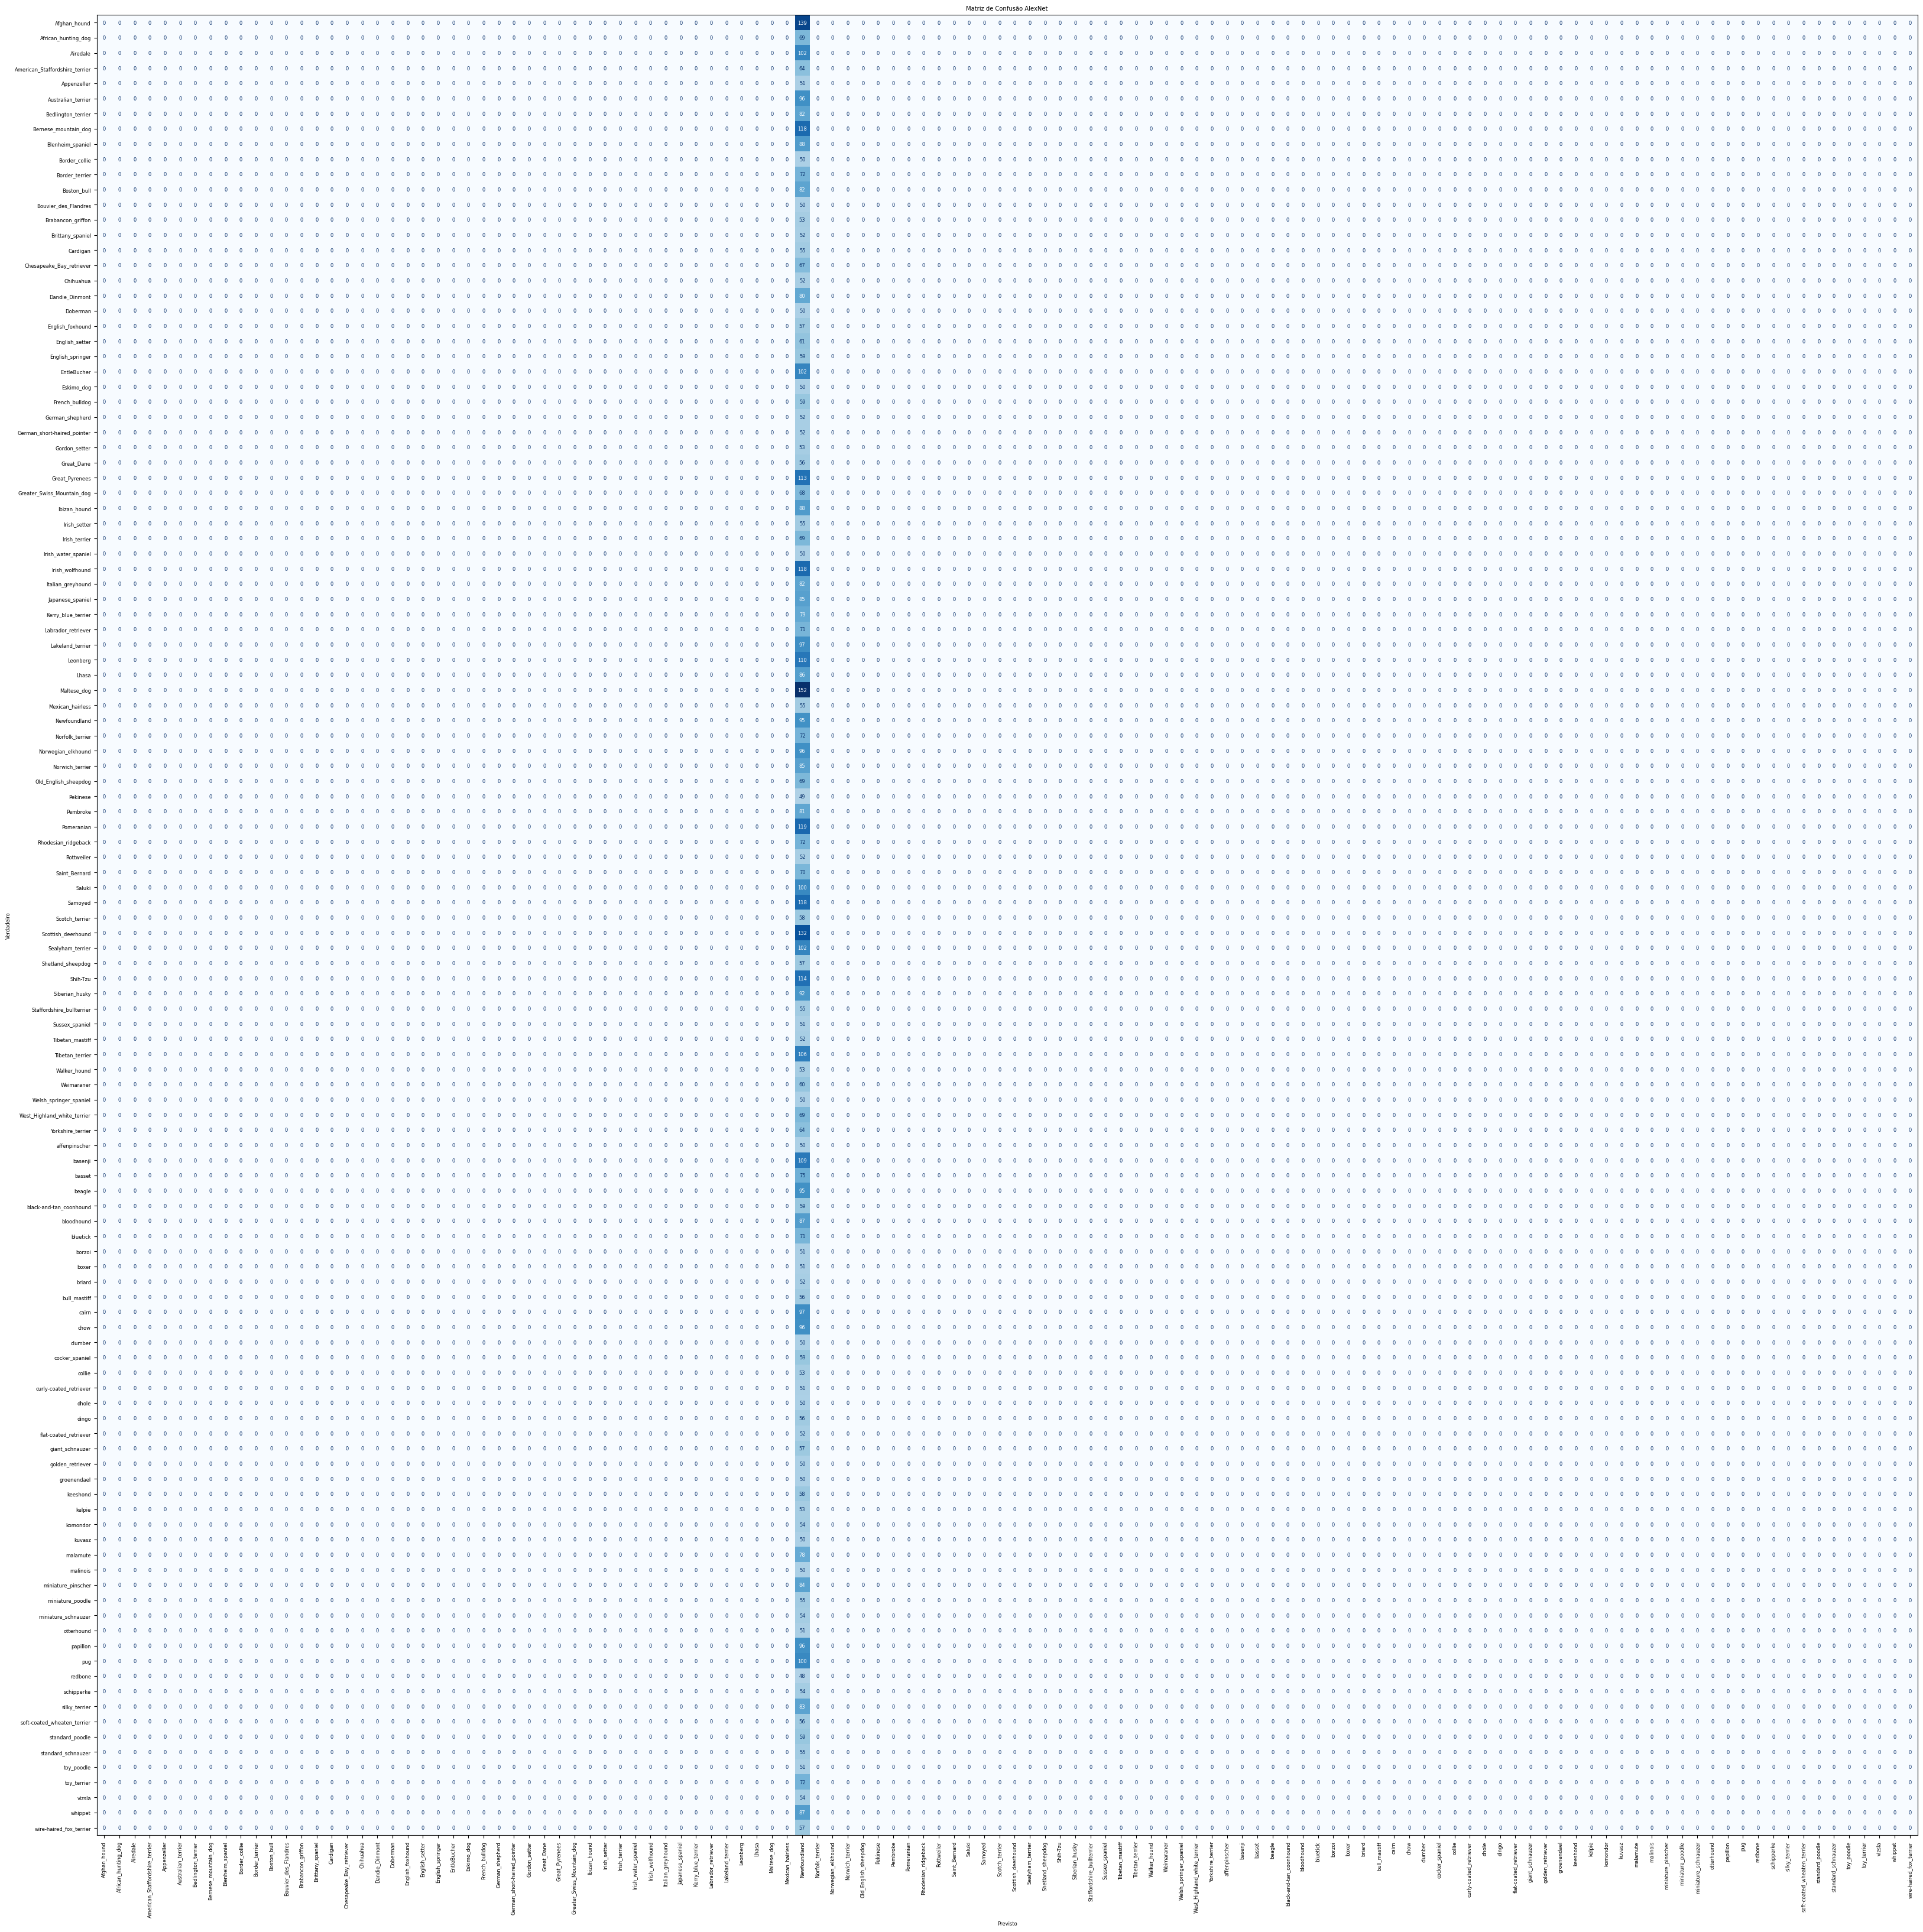

In [48]:
## melhorar a visualização da matriz de confusão, já que são 120 classes.
## tentei deixar mais legível mas as labels ainda estão pequenas.

cm = confusion_matrix(label, pred)
plt.figure(figsize=(40, 40))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_dataset.classes)
disp.plot(cmap='Blues', values_format='d', ax=plt.gca(), xticks_rotation=90, colorbar=False)
plt.title('Matriz de Confusão AlexNet')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.savefig('matriz_confusao.png', dpi=200)
plt.show()

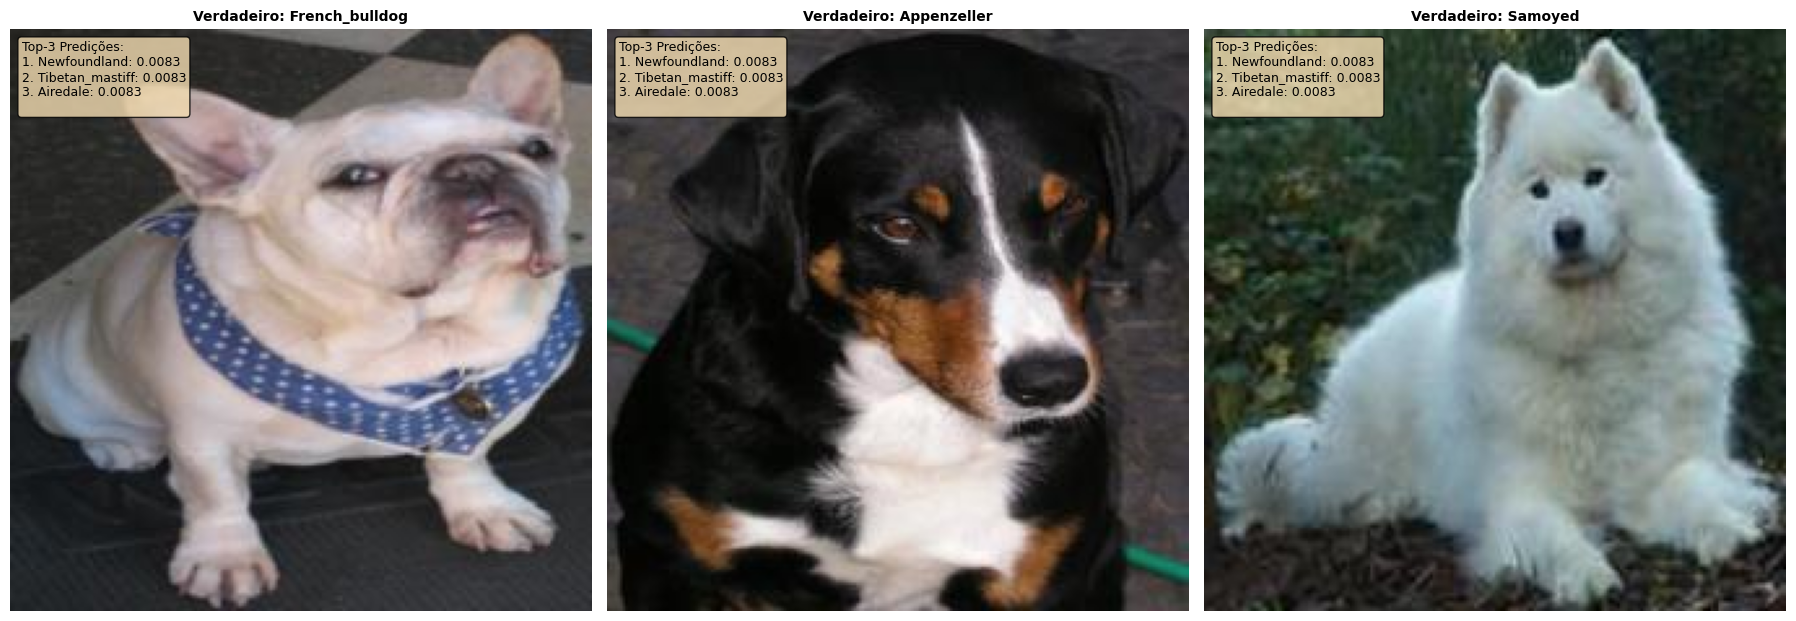

Exemplos aleatórios visualizados e salvos em 'top3_exemplos.png'


In [ ]:
def desnormalize(tensor):
    tensor = tensor.clone().detach()
    # Inverter normalização: x = (y * std) + mean
    # Nossas: mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]
    tensor = tensor * 0.5 + 0.5
    tensor = torch.clamp(tensor, 0, 1)
    return tensor

random.seed(42)
indices = random.sample(range(len(test_dataset)), 3)

# Exibir as 3 imagens com predições top-3
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, img_idx in enumerate(indices):
    image, true_label = test_dataset[img_idx]
    true_class_name = test_dataset.classes[true_label]

    image_batch = image.unsqueeze(0).to(device)
    with torch.no_grad():
        output = model_carregado(image_batch)

    probabilities = torch.nn.functional.softmax(output, dim=1)[0]
    top3_probs, top3_indices = torch.topk(probabilities, 3)
    
    # Desnormalizar para visualização
    image_display = desnormalize(image)
    image_display = image_display.permute(1, 2, 0).cpu().numpy()
    
    # Plot
    axes[idx].imshow(image_display)
    axes[idx].set_title(f"Verdadeiro: {true_class_name}", fontsize=10, fontweight='bold')
    
    # Adicionar top-3 predições como texto
    top3_text = "Top-3 Predições:\n"
    for i, (prob, class_idx) in enumerate(zip(top3_probs, top3_indices)):
        pred_class = test_dataset.classes[class_idx.item()]
        top3_text += f"{i+1}. {pred_class}: {prob.item():.4f}\n"
    
    axes[idx].text(0.02, 0.98, top3_text, transform=axes[idx].transAxes, 
                   fontsize=9, verticalalignment='top', 
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('top3_exemplos.png', dpi=150, bbox_inches='tight')
plt.show()

print("Exemplos aleatórios visualizados e salvos em 'top3_exemplos.png'")

## Parecer Avaliativo

- Elabore um parecer sobre o desempenho do modelo, elencando vantagens e limitações
- Faça a sugestão de três estratégias a serem incorporadas no modelo ou em seu treinamento para que haja melhoria de desempenho

A matriz de confusão revelou que o modelo está prevendo apenas uma única classe para praticamente todas as imagens do conjunto de teste.

### Erros cometidos

- A camada usa nn.Softmax(dim=1), mas o CrossEntropyLoss já aplica LogSoftmax internamente, o que causa dupla aplicação de normalizações causou instabilidade numérica. Nesse caso, a solução seria remover o softmax e deixar apenas os logits para CrossEntropyLoss, ou usar o LogSoftmax seguido de NLLLoss ao invés do CrossEntropyLoss, como dito na documentação.
- Além desse erro, o modelo foi treinado do zero em um problema com 120 classes, o que é muito difícil, e 120 épocas não são suficientes para isso. O correto seria usar transfer learning, partindo de um modelo já treinado no ImageNet, que já conhece texturas, formas, etc.
- As imagens foram apresentadas ao modelo sempre da mesma forma, sem variações de rotação, flip, brilho ou recorte, limitando a capacidade do modelo e generalizar para imagens que ele não viu exatamente igual durante o treino.

### Estratégias para melhorar o modelo

- Corrigir o Softmax redundante ou trocar a abordagem atual por LogSoftmax + NLLLoss
- Em vez de treinar do zero, carregar um modelo pré-treinado e substituir apenas a última camada, assim a rede já começa sabendo extrair atributos e precisa apenas aprender a diferenciar as raças entre si.
- Incluir variações aleatórias nas imagens de treino para ajudat o modelo a generalizar melhor

# Conclusão

O modelo no seu estado atual **não aprende**. Essa limitação é destacada pela análise da matriz de confusão, que revela a tendência do modelo de prever consistentemente uma única classe para a maioria das entradas, indicando uma incapacidade crítica de aprendizado e generalização. Apesar das outras sugestões que foram dadas, é possível ver como a redundância do Softmax afetou negativamente o modelo, e, então, é o erro principal deste.

Um ponto que é de desejo da equipe para futuras iterações é uma possível comparação do modelo atual com um futuro com as modificações apresentadas, que está sendo iterado separadamente e será adicionado no repositório separadamente para não causar confusão com a atividade a ser entregue, já que a equipe concordou em continuar com este objetivo mesmo sem a obrigatoriedade da entrega, pois esse foi um assunto que realmente nos interessamos.
